# Campaign Budget, Clicks, and Keyword EDA

This notebook performs three basic checks for the System Thinking Google Ads data:

1. Plot clicks versus daily budget for each region and campaign match-type configuration.
2. Check whether keyword inventory size is associated with click performance.
3. Compare overlap among the top 20 keywords across regions and match types.

Source files:

- `data/sys_think/processed/campaign-day-panel.csv`
- `data/sys_think/processed/campaign-summary.csv`
- `data/sys_think/processed/kw-day-panel.csv`

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_DIR = Path("data/sys_think/processed")
CAMPAIGN_DAY_PATH = DATA_DIR / "campaign-day-panel.csv"
CAMPAIGN_SUMMARY_PATH = DATA_DIR / "campaign-summary.csv"
KW_DAY_PATH = DATA_DIR / "kw-day-panel.csv"

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
campaign_day = pd.read_csv(CAMPAIGN_DAY_PATH, parse_dates=["date"])
campaign_summary = pd.read_csv(CAMPAIGN_SUMMARY_PATH, parse_dates=["start_date", "end_date"])
kw_day = pd.read_csv(KW_DAY_PATH, parse_dates=["date"])

print(f"campaign_day rows: {len(campaign_day):,}")
print(f"campaign_day date range: {campaign_day['date'].min().date()} to {campaign_day['date'].max().date()}")
print(f"kw_day rows: {len(kw_day):,}")
print(f"kw_day date range: {kw_day['date'].min().date()} to {kw_day['date'].max().date()}")
print(f"regions: {sorted(campaign_day['region'].dropna().unique())}")
print(f"campaign match configurations: {sorted(campaign_day['match_types'].dropna().unique())}")

campaign_day.head()

campaign_day rows: 2,222
campaign_day date range: 2024-06-26 to 2026-05-13
kw_day rows: 64,528
kw_day date range: 2022-07-01 to 2026-05-13
regions: ['A', 'B', 'C', 'USA']
campaign match configurations: ['Broad', 'Broad; Exact', 'Broad; Exact; Phrase', 'Broad; Phrase', 'Exact', 'Exact; Phrase', 'Phrase']


,date,campaign_version,region,daily_budget,match_types,clicks,cost
0,2024-06-26,13,B,38.830,Phrase,4,2.590
1,2024-06-27,7,A,58.250,Exact; Phrase,9,7.130
2,2024-06-27,13,B,38.830,Exact; Phrase,78,54.170
3,2024-06-27,4,C,19.420,Exact; Phrase,10,3.920
4,2024-06-27,22,USA,271.840,Phrase,3,5.220


## Clicks vs Daily Budget

The campaign-day panel is already keyed by date, region, campaign version, daily budget, and campaign match-type configuration. The first plot keeps every campaign-day observation. The second plot aggregates to one point per region, match configuration, and daily budget, which makes repeated budget levels easier to read.

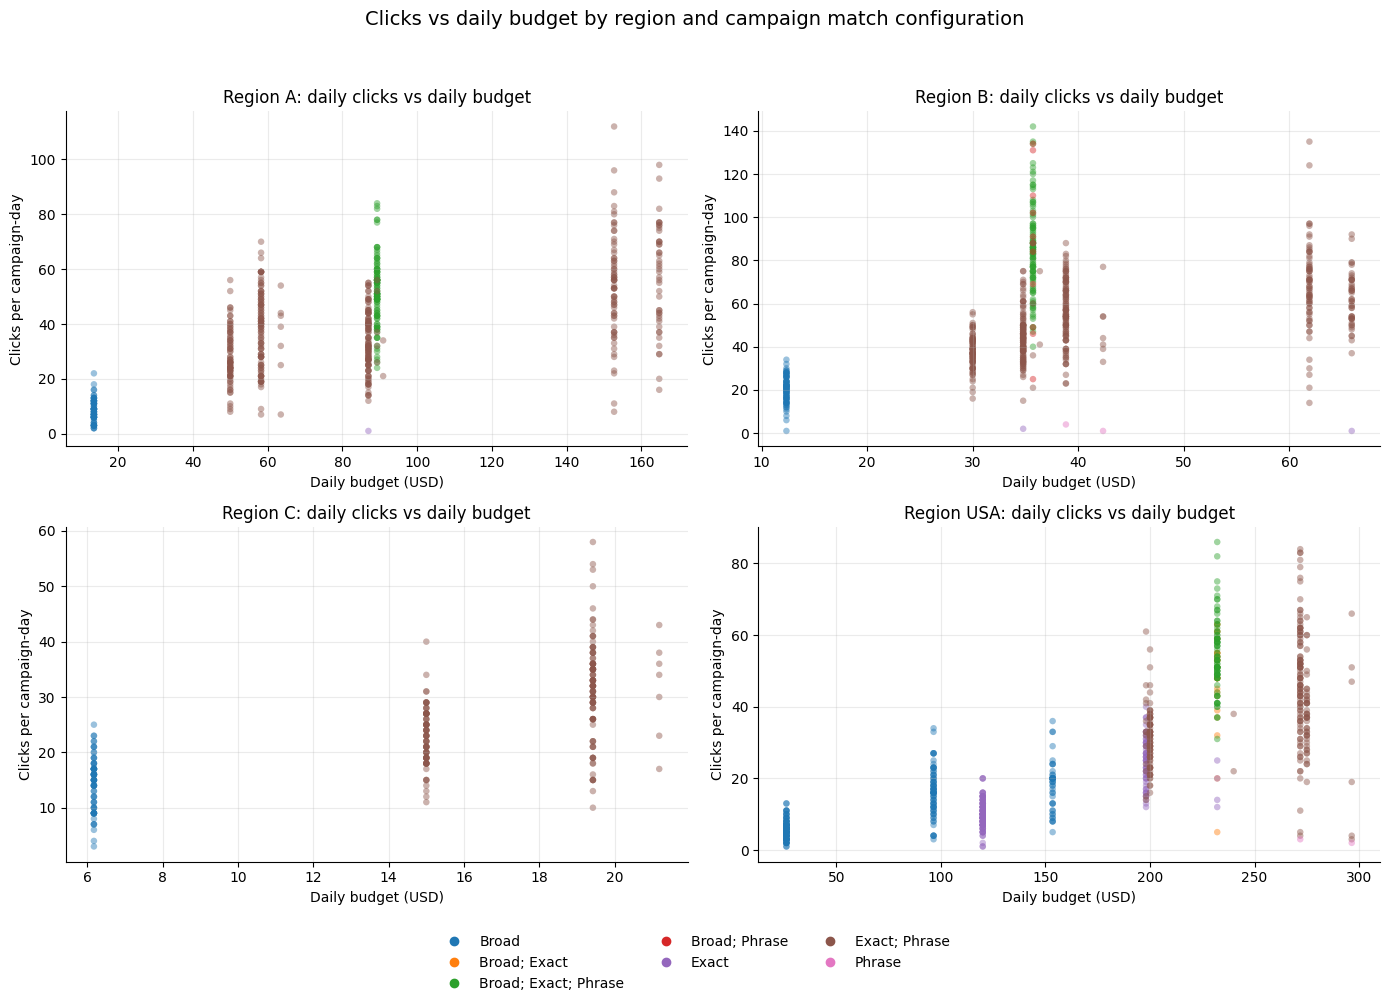

In [3]:
regions = sorted(campaign_day["region"].dropna().unique())
match_configs = sorted(campaign_day["match_types"].dropna().unique())
colors = dict(zip(match_configs, plt.cm.tab10.colors[: len(match_configs)]))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.ravel()

for ax, region in zip(axes, regions):
    sub = campaign_day[campaign_day["region"] == region]
    for match_config in match_configs:
        s = sub[sub["match_types"] == match_config]
        if s.empty:
            continue
        ax.scatter(
            s["daily_budget"],
            s["clicks"],
            s=22,
            alpha=0.45,
            label=match_config,
            color=colors[match_config],
            edgecolors="none",
        )
    ax.set_title(f"Region {region}: daily clicks vs daily budget")
    ax.set_xlabel("Daily budget (USD)")
    ax.set_ylabel("Clicks per campaign-day")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=colors[match_config], label=match_config)
    for match_config in match_configs
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Clicks vs daily budget by region and campaign match configuration", y=0.99, fontsize=14)
fig.tight_layout(rect=(0, 0.08, 1, 0.96))
plt.show()

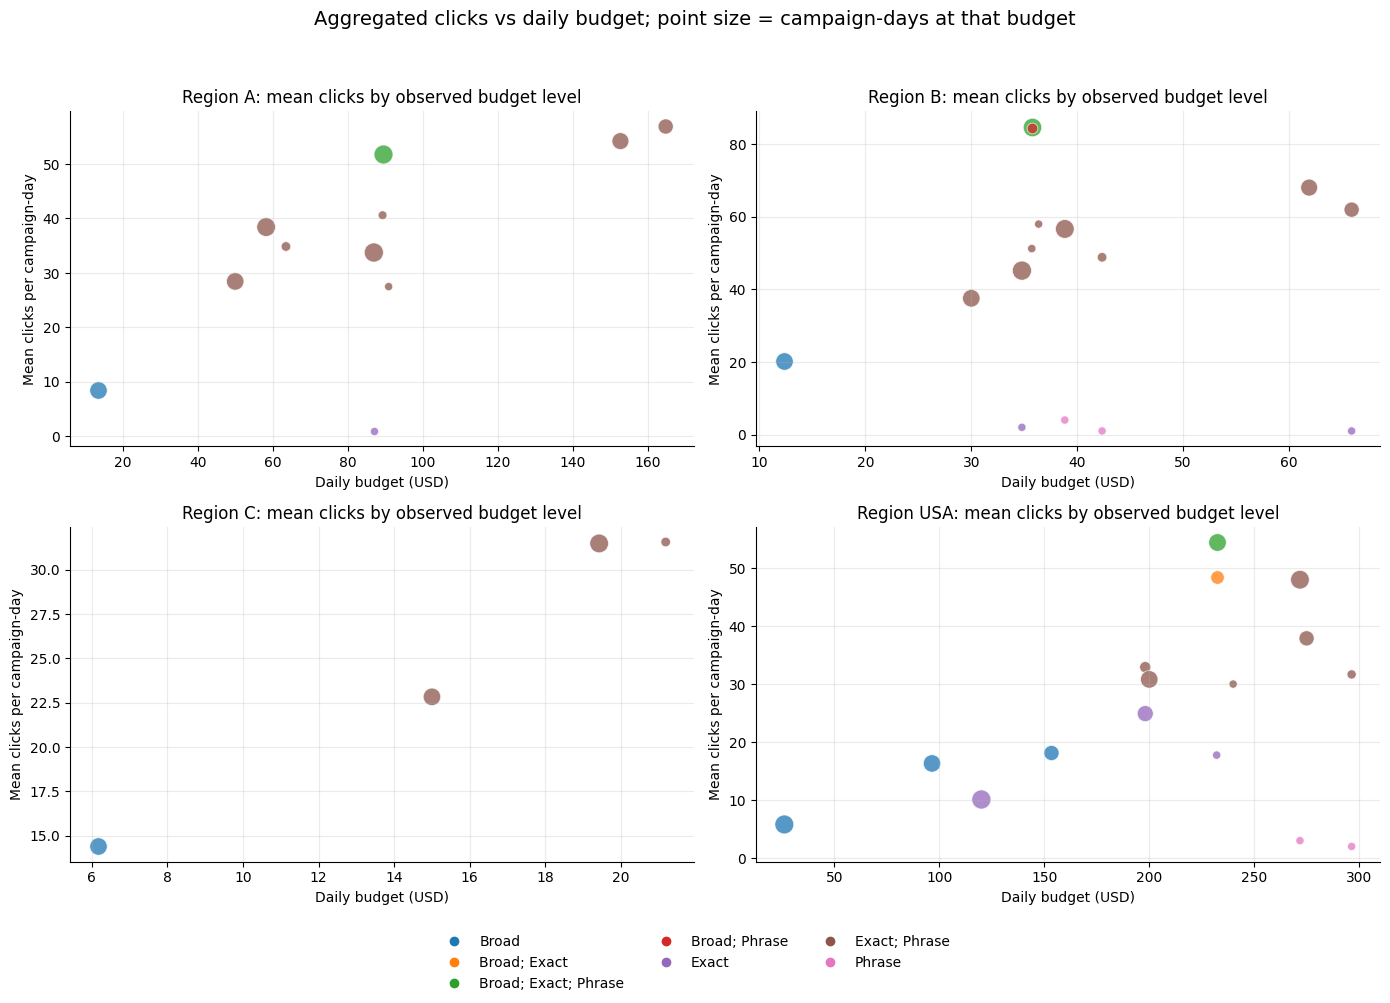

,region,match_types,daily_budget,mean_clicks,median_clicks,total_clicks,campaign_days
0,A,Broad,13.530,8.468,8.000,652,77
1,A,Broad; Exact; Phrase,89.290,51.832,51.000,5546,107
2,A,Exact,86.960,1.000,1.000,1,1
3,A,Exact; Phrase,50.000,28.449,26.000,2219,78
4,A,Exact; Phrase,58.250,38.422,40.000,3919,102
5,A,Exact; Phrase,63.530,34.857,39.000,244,7
6,A,Exact; Phrase,86.960,33.757,32.000,3747,111
7,A,Exact; Phrase,89.290,40.600,37.000,203,5
8,A,Exact; Phrase,90.910,27.500,27.500,55,2
9,A,Exact; Phrase,152.700,54.206,55.000,3686,68


In [4]:
budget_points = (
    campaign_day
    .groupby(["region", "match_types", "daily_budget"], as_index=False)
    .agg(
        mean_clicks=("clicks", "mean"),
        median_clicks=("clicks", "median"),
        total_clicks=("clicks", "sum"),
        campaign_days=("date", "nunique"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.ravel()

for ax, region in zip(axes, regions):
    sub = budget_points[budget_points["region"] == region]
    for match_config in match_configs:
        s = sub[sub["match_types"] == match_config]
        if s.empty:
            continue
        ax.scatter(
            s["daily_budget"],
            s["mean_clicks"],
            s=np.clip(np.sqrt(s["campaign_days"]) * 18, 35, 210),
            alpha=0.75,
            label=match_config,
            color=colors[match_config],
            edgecolors="white",
            linewidths=0.6,
        )
    ax.set_title(f"Region {region}: mean clicks by observed budget level")
    ax.set_xlabel("Daily budget (USD)")
    ax.set_ylabel("Mean clicks per campaign-day")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=colors[match_config], label=match_config)
    for match_config in match_configs
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Aggregated clicks vs daily budget; point size = campaign-days at that budget", y=0.99, fontsize=14)
fig.tight_layout(rect=(0, 0.08, 1, 0.96))
plt.show()

budget_points.sort_values(["region", "match_types", "daily_budget"]).head(20)

## Does Keyword Count Affect Click Performance?

Join the campaign-day panel to `campaign-summary.csv` by `campaign_version`, then compare keyword inventory size with two campaign-level performance metrics:

- `clicks_per_day`: average daily clicks for that campaign version.
- `clicks_per_100_budget`: average daily clicks normalized by daily budget.

This is descriptive EDA, not a causal estimate. Keyword count is confounded with region, match type, budget, timing, and campaign setup.

In [5]:
keyword_cols = [
    "campaign_version",
    "num_unique_keywords",
    "broad_keyword_count",
    "phrase_keyword_count",
    "exact_keyword_count",
    "num_negative_keywords",
]

campaign_perf = (
    campaign_day
    .merge(campaign_summary[keyword_cols], on="campaign_version", how="left")
    .groupby(
        [
            "campaign_version",
            "region",
            "match_types",
            "daily_budget",
            "num_unique_keywords",
            "broad_keyword_count",
            "phrase_keyword_count",
            "exact_keyword_count",
            "num_negative_keywords",
        ],
        as_index=False,
    )
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        campaign_days=("date", "nunique"),
        clicks=("clicks", "sum"),
        cost=("cost", "sum"),
        clicks_per_day=("clicks", "mean"),
    )
)

campaign_perf["clicks_per_100_budget"] = campaign_perf["clicks_per_day"] / campaign_perf["daily_budget"] * 100
campaign_perf["cost_per_click"] = campaign_perf["cost"] / campaign_perf["clicks"].replace(0, np.nan)

corr_rows = []
for metric in ["clicks_per_day", "clicks_per_100_budget", "cost_per_click"]:
    corr_rows.append(
        {
            "metric": metric,
            "pearson_corr_with_num_unique_keywords": campaign_perf["num_unique_keywords"].corr(campaign_perf[metric]),
            "n_campaign_versions": campaign_perf[["num_unique_keywords", metric]].dropna().shape[0],
        }
    )

corr_summary = pd.DataFrame(corr_rows)
print("Correlation across campaign versions")
display(corr_summary)

group_corr = []
for match_config, sub in campaign_perf.groupby("match_types"):
    if len(sub) < 3 or sub["num_unique_keywords"].nunique() < 2:
        continue
    group_corr.append(
        {
            "match_types": match_config,
            "n_campaign_versions": len(sub),
            "unique_keyword_counts": sub["num_unique_keywords"].nunique(),
            "corr_keywords_vs_clicks_per_day": sub["num_unique_keywords"].corr(sub["clicks_per_day"]),
            "corr_keywords_vs_clicks_per_100_budget": sub["num_unique_keywords"].corr(sub["clicks_per_100_budget"]),
        }
    )

group_corr = pd.DataFrame(group_corr).sort_values("match_types")
print("\nCorrelation within match configurations with enough variation")
display(group_corr)

campaign_perf.sort_values("clicks_per_day", ascending=False).head(15)[
    [
        "region",
        "match_types",
        "daily_budget",
        "num_unique_keywords",
        "campaign_days",
        "clicks_per_day",
        "clicks_per_100_budget",
        "clicks",
    ]
]

Correlation across campaign versions


,metric,pearson_corr_with_num_unique_keywords,n_campaign_versions
0,clicks_per_day,0.051,59
1,clicks_per_100_budget,0.078,59
2,cost_per_click,-0.259,59



Correlation within match configurations with enough variation


,match_types,n_campaign_versions,unique_keyword_counts,corr_keywords_vs_clicks_per_day,corr_keywords_vs_clicks_per_100_budget
0,Broad,6,2,-0.093,-0.809
1,Broad; Exact; Phrase,3,3,0.370,0.567
2,Exact,9,7,-0.727,-0.619
3,Exact; Phrase,35,15,-0.053,0.211
4,Phrase,4,2,0.000,-0.695


,region,match_types,daily_budget,num_unique_keywords,campaign_days,clicks_per_day,clicks_per_100_budget,clicks
41,B,Broad; Exact; Phrase,35.710,97,97,84.887,237.711,8234
42,B,Broad; Phrase,35.710,97,11,84.455,236.501,929
44,B,Exact; Phrase,61.900,97,54,69.611,112.457,3759
46,B,Exact; Phrase,61.900,6,3,66.667,107.701,200
19,B,Exact; Phrase,65.910,114,44,61.977,94.033,2727
47,B,Exact; Phrase,61.900,15,10,61.700,99.677,617
48,B,Exact; Phrase,36.360,15,2,58.000,159.516,116
9,A,Exact; Phrase,164.770,106,44,56.886,34.525,2503
13,B,Exact; Phrase,38.830,114,102,56.657,145.910,5779
36,A,Exact; Phrase,152.700,102,54,55.889,36.600,3018


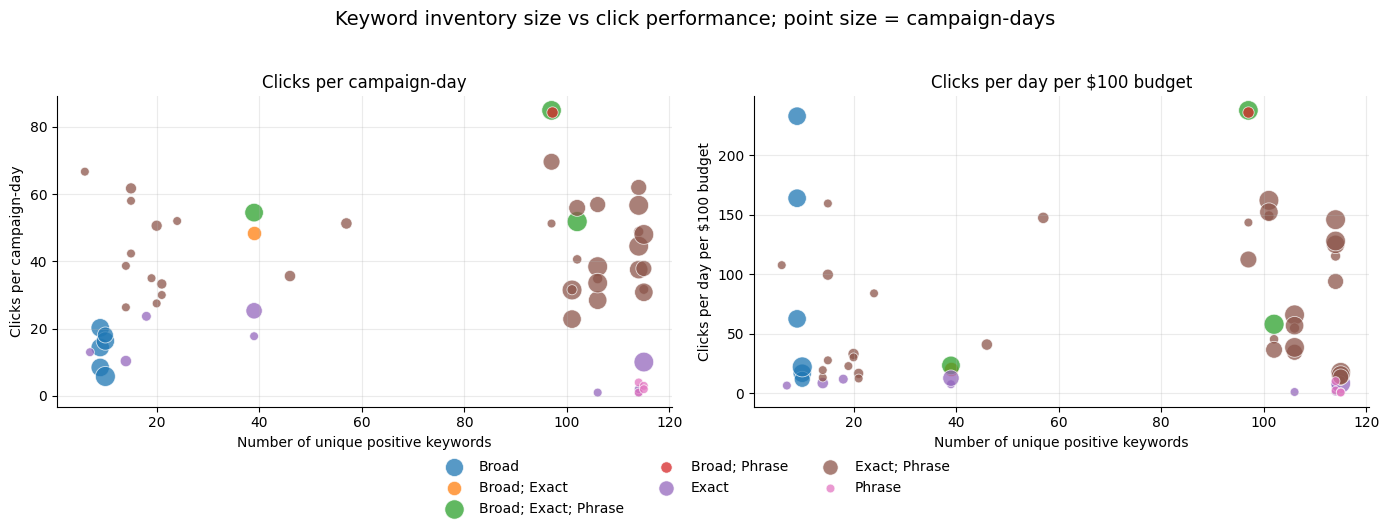

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_col, y_label in [
    (axes[0], "clicks_per_day", "Clicks per campaign-day"),
    (axes[1], "clicks_per_100_budget", "Clicks per day per $100 budget"),
]:
    for match_config in match_configs:
        sub = campaign_perf[campaign_perf["match_types"] == match_config]
        if sub.empty:
            continue
        ax.scatter(
            sub["num_unique_keywords"],
            sub[y_col],
            s=np.clip(np.sqrt(sub["campaign_days"]) * 20, 40, 220),
            alpha=0.75,
            label=match_config,
            color=colors[match_config],
            edgecolors="white",
            linewidths=0.6,
        )
    ax.set_xlabel("Number of unique positive keywords")
    ax.set_ylabel(y_label)
    ax.set_title(y_label)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Keyword inventory size vs click performance; point size = campaign-days", y=1.03, fontsize=14)
fig.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

## Top 20 Keyword Overlap Across Regions and Match Types

For this section, use the keyword-day panel and restrict it to the same date range covered by the campaign-day panel. Within each `(region, match_type)` group, rank keywords by total clicks and take the top 20. The overlap tables report how many keyword strings are shared between each pair of top-20 lists.

In [7]:
date_min = campaign_day["date"].min()
date_max = campaign_day["date"].max()
kw_window = kw_day[(kw_day["date"] >= date_min) & (kw_day["date"] <= date_max)].copy()

keyword_clicks = (
    kw_window
    .groupby(["region", "match_type", "keyword"], as_index=False)
    .agg(
        clicks=("clicks", "sum"),
        cost=("cost", "sum"),
        active_days=("date", "nunique"),
    )
)

top20 = (
    keyword_clicks
    .sort_values(["region", "match_type", "clicks", "active_days", "keyword"], ascending=[True, True, False, False, True])
    .groupby(["region", "match_type"], as_index=False)
    .head(20)
    .copy()
)
top20["rank"] = top20.groupby(["region", "match_type"])["clicks"].rank(method="first", ascending=False).astype(int)

print(f"Keyword-day rows in campaign-day date window: {len(kw_window):,}")
print(f"Top-20 groups found: {top20.groupby(['region', 'match_type']).ngroups}")

top20.head(30)

Keyword-day rows in campaign-day date window: 36,572
Top-20 groups found: 12


,region,match_type,keyword,clicks,cost,active_days,rank
60,A,Broad,system design certification,2360,"4,864.830",160,1
70,A,Broad,systems thinking certificate,702,"1,168.070",103,2
71,A,Broad,systems thinking course,395,666.410,143,3
50,A,Broad,project management methodologies,149,241.110,75,4
5,A,Broad,business systems course,143,189.130,56,5
49,A,Broad,project management cert,99,164.570,48,6
64,A,Broad,system dynamics course,85,149.750,62,7
13,A,Broad,coursera certificate,49,141.020,9,8
10,A,Broad,class central certificates,38,132.550,3,9
7,A,Broad,certificate for project,22,60.950,3,10


In [8]:
top_sets = {
    key: set(group["keyword"])
    for key, group in top20.groupby(["region", "match_type"])
}

all_pair_overlaps = []
for key_a, key_b in combinations(sorted(top_sets), 2):
    shared = top_sets[key_a] & top_sets[key_b]
    all_pair_overlaps.append(
        {
            "group_a": f"{key_a[0]} / {key_a[1]}",
            "group_b": f"{key_b[0]} / {key_b[1]}",
            "same_region": key_a[0] == key_b[0],
            "same_match_type": key_a[1] == key_b[1],
            "overlap_count": len(shared),
            "jaccard": len(shared) / len(top_sets[key_a] | top_sets[key_b]),
            "shared_keywords": "; ".join(sorted(shared)),
        }
    )

pair_overlap = pd.DataFrame(all_pair_overlaps).sort_values("overlap_count", ascending=False)

within_region_overlap = pair_overlap[pair_overlap["same_region"]].copy()
within_match_overlap = pair_overlap[pair_overlap["same_match_type"]].copy()

print("Highest top-20 overlaps across all region/match-type pairs")
display(pair_overlap.head(20))

print("\nOverlap across match types within the same region")
display(within_region_overlap.sort_values(["group_a", "group_b"]))

print("\nOverlap across regions within the same match type")
display(within_match_overlap.sort_values(["group_a", "group_b"]))

Highest top-20 overlaps across all region/match-type pairs


,group_a,group_b,same_region,same_match_type,overlap_count,jaccard,shared_keywords
23,A / Phrase,B / Phrase,False,True,15,0.600,certificate course on business management; con...
29,A / Phrase,USA / Phrase,False,True,15,0.600,critical thinking and problem solving; how to ...
43,B / Exact,USA / Exact,False,True,15,0.600,best critical thinking courses; how to train p...
47,B / Phrase,C / Phrase,False,True,15,0.600,certificate course on business management; cri...
50,B / Phrase,USA / Phrase,False,True,14,0.538,critical thinking and problem solving; how to ...
62,C / Phrase,USA / Phrase,False,True,14,0.538,critical thinking and problem solving; critica...
13,A / Exact,B / Exact,False,True,14,0.538,best critical thinking courses; learning syste...
19,A / Exact,USA / Exact,False,True,14,0.538,best critical thinking courses; learning syste...
26,A / Phrase,C / Phrase,False,True,13,0.481,certificate course on business management; cri...
40,B / Exact,C / Exact,False,True,13,0.481,best critical thinking courses; how to train p...



Overlap across match types within the same region


,group_a,group_b,same_region,same_match_type,overlap_count,jaccard,shared_keywords
0,A / Broad,A / Exact,True,False,4,0.111,best critical thinking courses; project manage...
1,A / Broad,A / Phrase,True,False,2,0.053,project management cert; systems thinking cert...
11,A / Exact,A / Phrase,True,False,6,0.176,lms learning program; mit systems thinking; pr...
30,B / Broad,B / Exact,True,False,5,0.143,best critical thinking courses; project manage...
31,B / Broad,B / Phrase,True,False,1,0.026,project management cert
38,B / Exact,B / Phrase,True,False,6,0.176,lms learning program; project management cert;...
51,C / Broad,C / Exact,True,False,4,0.160,best critical thinking courses; best systems t...
52,C / Broad,C / Phrase,True,False,1,0.036,project management cert
56,C / Exact,C / Phrase,True,False,5,0.143,how to learn to think strategically; lms learn...
63,USA / Broad,USA / Exact,True,False,6,0.176,best critical thinking courses; introduction t...



Overlap across regions within the same match type


,group_a,group_b,same_region,same_match_type,overlap_count,jaccard,shared_keywords
2,A / Broad,B / Broad,False,True,9,0.290,best critical thinking courses; business syste...
5,A / Broad,C / Broad,False,True,7,0.318,best critical thinking courses; business syste...
8,A / Broad,USA / Broad,False,True,8,0.250,best critical thinking courses; business syste...
13,A / Exact,B / Exact,False,True,14,0.538,best critical thinking courses; learning syste...
16,A / Exact,C / Exact,False,True,11,0.379,best critical thinking courses; best systems t...
19,A / Exact,USA / Exact,False,True,14,0.538,best critical thinking courses; learning syste...
23,A / Phrase,B / Phrase,False,True,15,0.600,certificate course on business management; con...
26,A / Phrase,C / Phrase,False,True,13,0.481,certificate course on business management; cri...
29,A / Phrase,USA / Phrase,False,True,15,0.600,critical thinking and problem solving; how to ...
32,B / Broad,C / Broad,False,True,8,0.381,best critical thinking courses; business syste...


,A / Broad,A / Exact,A / Phrase,B / Broad,B / Exact,B / Phrase,C / Broad,C / Exact,C / Phrase,USA / Broad,USA / Exact,USA / Phrase
A / Broad,20,4,2,9,5,1,7,3,1,8,5,2
A / Exact,4,20,6,4,14,5,5,11,4,5,14,5
A / Phrase,2,6,20,2,6,15,1,7,13,3,6,15
B / Broad,9,4,2,20,5,1,8,3,1,10,5,2
B / Exact,5,14,6,5,20,6,5,13,6,5,15,4
B / Phrase,1,5,15,1,6,20,1,5,15,2,4,14
C / Broad,7,5,1,8,5,1,9,4,1,9,5,1
C / Exact,3,11,7,3,13,5,4,20,5,4,13,5
C / Phrase,1,4,13,1,6,15,1,5,20,2,5,14
USA / Broad,8,5,3,10,5,2,9,4,2,20,6,3


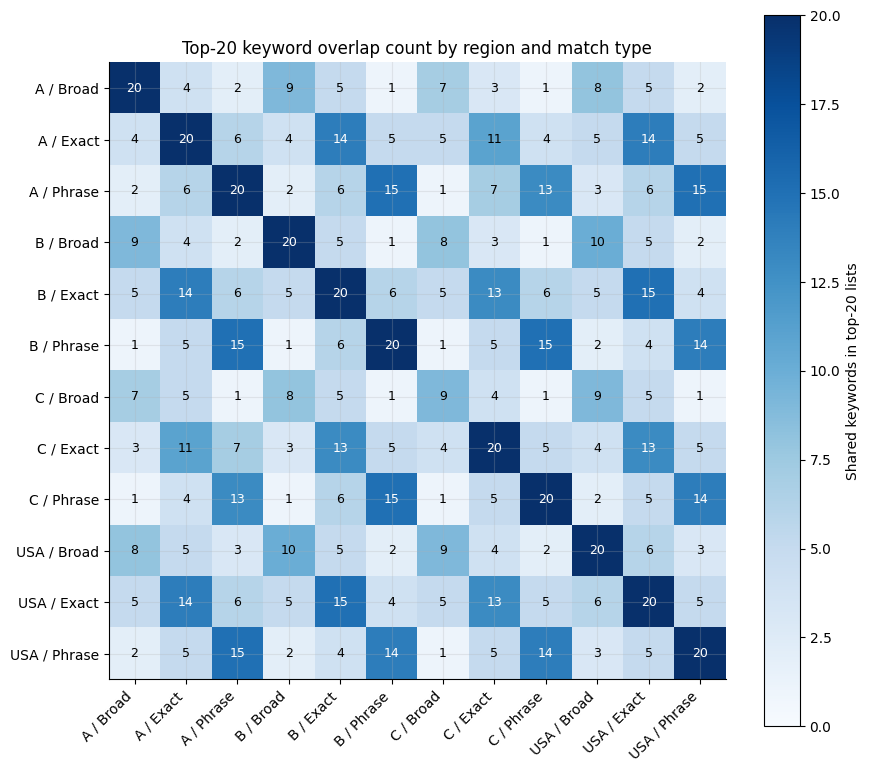

In [9]:
overlap_matrix = pd.DataFrame(index=[f"{k[0]} / {k[1]}" for k in sorted(top_sets)], columns=[f"{k[0]} / {k[1]}" for k in sorted(top_sets)], dtype=float)

for key_a in sorted(top_sets):
    for key_b in sorted(top_sets):
        overlap_matrix.loc[f"{key_a[0]} / {key_a[1]}", f"{key_b[0]} / {key_b[1]}"] = len(top_sets[key_a] & top_sets[key_b])

display(overlap_matrix.astype(int))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(overlap_matrix.values.astype(float), cmap="Blues", vmin=0, vmax=20)
ax.set_xticks(range(len(overlap_matrix.columns)))
ax.set_xticklabels(overlap_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(overlap_matrix.index)))
ax.set_yticklabels(overlap_matrix.index)
ax.set_title("Top-20 keyword overlap count by region and match type")

for i in range(overlap_matrix.shape[0]):
    for j in range(overlap_matrix.shape[1]):
        value = int(overlap_matrix.iloc[i, j])
        ax.text(j, i, value, ha="center", va="center", color="black" if value < 12 else "white", fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Shared keywords in top-20 lists")
fig.tight_layout()
plt.show()

## Quick Takeaways

- Across campaign versions, the relationship between number of unique positive keywords and click volume is very weak in this cut of the data: Pearson correlation is about `0.05` for clicks per day and `0.08` for clicks per day per $100 of budget.
- The highest click-per-day configurations are mostly Region B campaigns, especially mixed Broad/Exact/Phrase or Broad/Phrase configurations at a $35.71 daily budget.
- Top-20 keyword lists overlap much more across regions within the same individual match type than across match types within a region. The largest overlaps found here are 15 shared keywords out of 20 for Phrase across A/B, A/USA, and B/C, and for Exact across B/USA.
- Within a single region, Exact-vs-Phrase top-20 overlap is lower: 6 shared keywords in A, 6 in B, 5 in C, and 5 in USA.